# Exercise Graph III

In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [10]:
class AgentState(TypedDict): # Our State Schema
    name: str
    age: int
    skills: List[str]
    result: str

In [11]:
def first_node(state: AgentState) -> AgentState:
    """This function handles the first node greeting the user"""
    state['result'] = f"{state['name']}, welcome to system! "
    return state
def second_node(state: AgentState) -> AgentState:
    """This function handles the second node adding the age of the user"""
    state['result'] += f"You are {state['age']} years old! "
    return state
def third_node(state: AgentState) -> AgentState:
    """This function handles the third node adding the skills of the user"""
    skills = state['skills']
    skills[len(skills) - 1] = "and " + skills[len(skills) - 1]
    skills_str = ', '.join(skills)
    state['result'] += f"You have skills in : {skills_str}."
    return state

In [12]:
graph = StateGraph(AgentState)
graph.add_node('first_node', first_node)
graph.add_node('second_node', second_node)
graph.add_node('third_node', third_node)
graph.set_entry_point('first_node')
graph.add_edge('first_node', 'second_node')
graph.add_edge('second_node', 'third_node')
graph.set_finish_point('third_node')

app = graph.compile()

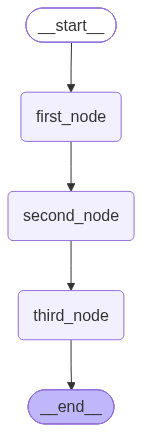

In [13]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
result = app.invoke({"name" : "Linda", "age" : 31, "skills": ["Python", "Machine Learning", "LangGraph"]})
result['result']

'Linda, welcome to system! You are 31 years old! You have skills in : Python, Machine Learning, and LangGraph.'